## **UPSC SA Evaluator using Langgraph**

In [10]:
from langgraph.graph import StateGraph, START,END 
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv 
from typing import TypedDict, Annotated
from pydantic import BaseModel,Field 
import operator

In [2]:
load_dotenv()

True

In [3]:
model = ChatOpenAI(model='gpt-4o-mini')

In [ ]:
# Defining schema/rule for the model with pydantic 

class EvaluationSchema(BaseModel):
    feedback: str = Field(description="Detailed feeback for essay")
    score: int = Field(description='Score out of 10',ge=0,le=10)

In [7]:
structured_model = model.with_structured_output(EvaluationSchema)

In [6]:
essay = """
India has emerged as one of the fastest-growing hubs for artificial intelligence (AI) development. With a large pool of skilled engineers, data scientists, and researchers, the country has a strong human capital base for AI innovation. The Government of India launched the “National AI Strategy” under NITI Aayog to guide AI adoption across sectors, emphasizing five key areas: healthcare, agriculture, education, smart cities, and smart mobility. India is also promoting AI research through initiatives like the National AI Portal and the AI Research Analytics and Knowledge Dissemination Platform (AIRAWAT), which encourage collaboration between academia, industry, and government bodies.

Start-ups and technology firms in India are increasingly focusing on AI-driven products and services, while multinational corporations have set up AI research centers in cities such as Bengaluru, Hyderabad, and Pune. The country’s vibrant IT industry and outsourcing expertise provide a foundation for large-scale AI projects, and Indian academic institutions like the IITs and IISc are offering specialized AI programs to create a future-ready workforce. Government policies also encourage AI adoption in public services, including smart governance and digital identity systems, making India a testing ground for innovative solutions.

"""

In [8]:
# generate prompt 
prompt = f"Evaluate the language quality of the following essay and provide feedback on the essay and assign a score out of 10\n{essay}"
structured_model.invoke(prompt).feedback

"The essay presents a well-structured overview of India's growing role in the field of artificial intelligence. The language is clear and straightforward, effectively communicating the main points. The use of specific initiatives and examples, such as the National AI Strategy and AIRAWAT, adds credibility and depth to the discussion. However, the essay could benefit from a more engaging introduction to draw the reader in and a concluding statement that summarizes the key takeaways or offers insights into the future of AI in India. Additionally, including more diverse vocabulary and transition phrases could enhance the overall flow of the writing."

In [13]:
# Now we can define the state class 

class UPSCState(TypedDict):

    essay: str 
    language_feedback: str 
    analysis_feedback: str
    clarity_feedback: str 
    overall_feedback: str 
    individual_score: Annotated[list[int],operator.add]
    avg_score: float 

In [14]:
# function to evaluate the language of the essay 

def evaluate_language(state:UPSCState):
    prompt = f"Evaluate the language quality of the following essay and provide feedback and assign a score out of 10\n{state['essay']}"
    output = structured_model.invoke(prompt)

    return {'language_feedback':output.feedback, 'individual_score':[output.score]}


In [16]:
# function to evaluate the language of the essay 

def evaluate_analysis(state:UPSCState):
    prompt = f"Evaluate the depth of analysis of the following essay and provide feedback and assign a score out of 10\n{state['essay']}"
    output = structured_model.invoke(prompt)

    return {'analysis_feedback':output.feedback, 'individual_score':[output.score]}


In [ ]:
# function to evaluate the language of the essay 

def evaluate_thought(state:UPSCState):
    prompt = f"Evaluate the clarity of the thought of the following essay and provide feedback and assign a score out of 10\n{state['essay']}"
    output = structured_model.invoke(prompt)
 
    return {'clarity_feedback':output.feedback, 'individual_score':[output.score]}


In [18]:
# function to get the ovrerall feedback 
def final_evaluation(state:UPSCState):

    prompt = f'Based on the given feedbacks to you kindly create a summerized feedback- {state["language_feedback"]} \n depth of analysis feedback - {state["analysis_feedback"]} \n clarity of thought feedback- {state["clarity_feedback"]}'
    overall_feedback = model.invoke(prompt).content 

    # avg calculate 
    avg_score = sum(state['individual_score'])/len(state["individual_score"])

    return {"overal_feedback":overall_feedback, 'avg_score':avg_score}



In [30]:
graph = StateGraph(UPSCState)

In [31]:
# adding nodes 

graph.add_node('evaluate_language',evaluate_language)
graph.add_node("evaluate_analysis",evaluate_analysis)
graph.add_node("evaluate_thought",evaluate_thought)
graph.add_node('final_evaluation',final_evaluation)


# adding edges 
graph.add_edge(START, 'evaluate_language')
graph.add_edge(START, 'evaluate_analysis')
graph.add_edge(START, "evaluate_thought")

graph.add_edge("evaluate_language","final_evaluation")
graph.add_edge("evaluate_analysis","final_evaluation")
graph.add_edge("evaluate_thought","final_evaluation")


graph.add_edge('final_evaluation',END)

# compile the graph 
workflow = graph.compile()

# if you are getting the wrror saying teh node already exist in the graph then you need to define the graph again and then, sometimes it happens by running the cell multiple times 


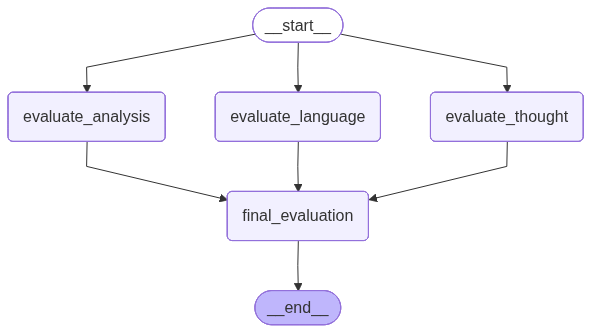

In [28]:
workflow

In [32]:
essay1 = """
Tadoba Tiger Reserve, located in Maharashtra, is one of 
India’s oldest and largest national parks. It is renowned for 
its dense forests, rich biodiversity, and thriving tiger 
population. The reserve is part of the Tadoba-Andhari 
landscape, combining the Tadoba National Park and Andhari 
Wildlife Sanctuary. It provides a natural habitat for Bengal 
tigers, leopards, sloth bears, wild dogs, and numerous bird 
species. Tourists visit the park for thrilling jungle safaris 
and a chance to observe wildlife in its natural surroundings. 
Tadoba also plays a crucial role in conserving endangered 
species and maintaining ecological balance. 
The lush teak forests and serene lakes within the reserve 
enhance its scenic beauty. Local communities around Tadoba 
benefit from eco-tourism initiatives that create employment 
and promote conservation awareness. Seasonal variations offer 
different experiences, with the summer months being ideal for 
spotting tigers near water bodies. Overall, 
adoba Tiger Reserve stands as a symbol of India’s 
commitment to wildlife conservation and sustainable tourism.
"""

In [33]:
initial_state= {
    'essay':essay1
}

workflow.invoke(initial_state)

{'essay': '\nTadoba Tiger Reserve, located in Maharashtra, is one of \nIndia’s oldest and largest national parks. It is renowned for \nits dense forests, rich biodiversity, and thriving tiger \npopulation. The reserve is part of the Tadoba-Andhari \nlandscape, combining the Tadoba National Park and Andhari \nWildlife Sanctuary. It provides a natural habitat for Bengal \ntigers, leopards, sloth bears, wild dogs, and numerous bird \nspecies. Tourists visit the park for thrilling jungle safaris \nand a chance to observe wildlife in its natural surroundings. \nTadoba also plays a crucial role in conserving endangered \nspecies and maintaining ecological balance. \nThe lush teak forests and serene lakes within the reserve \nenhance its scenic beauty. Local communities around Tadoba \nbenefit from eco-tourism initiatives that create employment \nand promote conservation awareness. Seasonal variations offer \ndifferent experiences, with the summer months being ideal for \nspotting tigers near